<a href="https://colab.research.google.com/github/linda-bsharat/telco-customer-churn-prediction/blob/main/notebooks/01_data_cleaning_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Telco Customer Churn Project**







###**01- Data cleaning and handling missing values**
The dataset contains approximately 70,000 customer records and 21 features describing customer demographics, service subscriptions, account information, and billing details.

Each row represents one customer.

The target variable is:



*   Churn (Yes/No) — indicating whether the customer left the service.

Key features include:

*   Demographics (gender, senior citizen, partner, dependents)
*   Account information (tenure, contract type, payment method)
*   Services (internet service, tech support, streaming services)
*   Billing information (monthly charges, total charges)

###  1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###  2. Load Data

In [4]:
# Load the dataset

url = "../data/telco_customer_data_v2.csv"
df = pd.read_csv(url)

# Display first rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No
2,CUST00003,Female,No,No,No,42.0,Yes,Yes,DSL,No,...,No,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
4,CUST00005,Male,Yes,Yes,Yes,17.0,Yes,NaN,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes


###   3. Initial Data Exploration

In [5]:
# Check dataset shape
df.shape

(70000, 21)

In [6]:
# View column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        70000 non-null  str    
 1   gender            69252 non-null  str    
 2   SeniorCitizen     69341 non-null  str    
 3   Partner           66470 non-null  str    
 4   Dependents        66435 non-null  str    
 5   tenure            69433 non-null  float64
 6   PhoneService      70000 non-null  str    
 7   MultipleLines     68132 non-null  str    
 8   InternetService   70000 non-null  str    
 9   OnlineSecurity    67078 non-null  str    
 10  OnlineBackup      67253 non-null  str    
 11  DeviceProtection  67106 non-null  str    
 12  TechSupport       67267 non-null  str    
 13  StreamingTV       67173 non-null  str    
 14  StreamingMovies   67215 non-null  str    
 15  Contract          70000 non-null  str    
 16  PaperlessBilling  70000 non-null  str    
 17  Paym

In [8]:
# Statistical summary
df.describe()

,tenure,MonthlyCharges
count,69433.000000,69612.000000
mean,30.516858,60.588548
std,89.873767,111.509588
min,-10.000000,18.000000
25%,10.000000,29.670000
50%,20.000000,41.190000
75%,35.000000,63.882500
max,999.000000,1499.770000


###  3. Data Cleaning (Handle Missing Values)


In [9]:
df.isna().sum().sort_values(ascending=False).head(15)

PaymentMethod       3569
Dependents          3565
Partner             3530
OnlineSecurity      2922
DeviceProtection    2894
StreamingTV         2827
StreamingMovies     2785
OnlineBackup        2747
TechSupport         2733
MultipleLines       1868
TotalCharges        1062
gender               748
SeniorCitizen        659
tenure               567
MonthlyCharges       388
dtype: int64


*   ###  Cleaning Binary Columns (Yes/No)



In [10]:
# List of service-related columns that contain Yes/No values

service_cols = [
    "Dependents",
    "Partner",
    "OnlineSecurity",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies",
    "OnlineBackup",
    "TechSupport",
    "MultipleLines",
]

# Fill missing values with "No"

df[service_cols] = df[service_cols].fillna("No")





*   ### Missing data




In [11]:
# Check the columns with the highest number of missing values

df.isna().sum().sort_values(ascending=False).head(15)

PaymentMethod       3569
TotalCharges        1062
gender               748
SeniorCitizen        659
tenure               567
MonthlyCharges       388
Dependents             0
customerID             0
Partner                0
OnlineSecurity         0
PhoneService           0
MultipleLines          0
InternetService        0
TechSupport            0
DeviceProtection       0
dtype: int64

*   ### Fix TotalCharges type

In [12]:
# Convert TotalCharges column to numeric
# Any invalid values will be converted to NaN

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

*  ### Handle numeric missing (tenure, MonthlyCharges)

In [13]:
# Fill missing values in numerical columns using the median

df["tenure"] = df["tenure"].fillna(df["tenure"].median())
df["MonthlyCharges"] = df["MonthlyCharges"].fillna(df["MonthlyCharges"].median())

*   ### Impute TotalCharges using tenure * MonthlyCharges

In [14]:
# Create a mask to locate rows where TotalCharges is missing

mask = df["TotalCharges"].isna()

# Estimate missing TotalCharges using: TotalCharges ≈ tenure * MonthlyCharges

df.loc[mask, "TotalCharges"] = (
    df.loc[mask, "tenure"] * df.loc[mask, "MonthlyCharges"]
)

In [15]:
# Check remaining missing values after handling TotalCharges

df.isna().sum().sort_values(ascending=False)

PaymentMethod       3569
gender               748
SeniorCitizen        659
Partner                0
customerID             0
Dependents             0
tenure                 0
MultipleLines          0
PhoneService           0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
InternetService        0
TechSupport            0
StreamingTV            0
Contract               0
StreamingMovies        0
PaperlessBilling       0
MonthlyCharges         0
TotalCharges           0
Churn                  0
dtype: int64

*   ### Handle demographic missing values




In [16]:
# Fill missing values in categorical columns using the most frequent value (mode)

df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["SeniorCitizen"] = df["SeniorCitizen"].fillna(df["SeniorCitizen"].mode()[0])

In [17]:
# Check again for remaining missing values

df.isna().sum().sort_values(ascending=False).head(3)

PaymentMethod    3569
gender              0
SeniorCitizen       0
dtype: int64

In [18]:
# Inspect the distribution of values in PaymentMethod column

df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             27841
Bank transfer (automatic)    14102
Mailed check                 13963
Credit card (automatic)      10400
BANK TRANSFER                  125
Name: count, dtype: int64

In [19]:
# Display rows where PaymentMethod values are missing
df[df["PaymentMethod"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
88,CUST00089,Female,1,No,No,14.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,NaN,37.44,524.16,Yes
90,CUST00091,Male,0,No,No,22.0,Yes,No,DSL,No,...,No,No,No internet service,No,Month-to-month,Yes,NaN,41.19,906.18,Yes
109,CUST00110,FEMALE,No,No,No,11.0,Yes,Yes,DSL,No,...,No internet service,No,No,No internet service,Two year,Yes,NaN,18.39,202.29,No
113,CUST00114,Female,0,Yes,Yes,21.0,No,No phone service,Fiber optic,No,...,No,No,No,No,Two year,No,NaN,25.91,544.11,No
159,CUST00160,Male,0,No,Yes,10.0,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,NaN,29.91,299.10,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69874,CUST69875,Male,0,No,Yes,18.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,One year,Yes,NaN,41.19,741.42,No
69901,CUST69902,Female,0,No,Yes,30.0,Yes,No,DSL,No,...,No,No,No,No,Two year,No,NaN,46.09,1382.70,No
69933,CUST69934,Female,No,Yes,Yes,35.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,NaN,41.19,1441.65,No
69936,CUST69937,Male,0,No,No,7.0,Yes,No,DSL,No,...,Yes,No,No,No,One year,Yes,NaN,29.43,206.01,Yes



    
*   ### Handle PaymentMethod missing values


In [20]:
# Fill missing values in PaymentMethod using the most frequent category

df["PaymentMethod"] = df["PaymentMethod"].fillna(df["PaymentMethod"].mode()[0])

In [21]:
# Verify that no missing values remain in the dataset

df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64



*   ### FIXING GENDER COLUMS




In [22]:
# Standardize gender values by removing spaces and formatting text
df['gender'] = df['gender'].str.strip().str.capitalize()
# Replace shorthand gender values with standard labels
df['gender'] = df['gender'].replace({'F': 'Female', 'M': 'Male'})
# Correct inconsistent gender label
df['gender'] = df['gender'].replace({ 'Man': 'Male'})

In [23]:
# Check the distribution of gender values after cleaning
df["gender"].value_counts()

gender
Female    35535
Male      34465
Name: count, dtype: int64



*   ### FIXING SENIOR CITIZEN COLUMNS




In [24]:
# Convert SeniorCitizen column to binary numeric values

df["SeniorCitizen"] = df["SeniorCitizen"].replace({
    "Yes": 1,
    "No": 0,
    "not senior": 0})
# Ensure the column is stored as integer type
df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)

In [25]:
# Verify the distribution of SeniorCitizen values

df["SeniorCitizen"].value_counts()

SeniorCitizen
0    56053
1    13947
Name: count, dtype: int64



*   ###  Target Variable Cleaning (Churn)




In [26]:
# Check the distribution of the target variable (Churn)
df["Churn"].value_counts()

Churn
No          37057
Yes         32713
Unknown        54
N              46
CHURNED        46
NO CHURN       45
Y              39
Name: count, dtype: int64



*   ### CONVARTE DATA IN CHURN



In [27]:
# Enable strict behavior for future pandas type conversions

pd.set_option('future.no_silent_downcasting', True)

# Standardize different churn labels into binary values

df['Churn'] = df['Churn'].replace({
    'Yes': 1, 'Y': 1, 'CHURNED': 1,
    'No': 0, 'N': 0, 'NO CHURN': 0,
    'Unknown': None
})

# Remove rows where churn status is unknown
df = df.dropna(subset=['Churn'])
# Convert churn column to integer type
df['Churn'] = df['Churn'].astype(int)



C:\Users\hp\AppData\Local\Temp\ipykernel_19672\2431819.py:3: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [28]:
# Check the final distribution of the churn target variable
df["Churn"].value_counts()


Churn
0    37148
1    32798
Name: count, dtype: int64



*   ### Standardize PaymentMethod




In [29]:
# Replace inconsistent naming of payment method with a standardized format

df['PaymentMethod'] = df['PaymentMethod'].replace({
    'BANK TRANSFER': 'Bank transfer (automatic)'
})

# Display the count of each payment method to verify the cleaning step

df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             31379
Bank transfer (automatic)    14215
Mailed check                 13959
Credit card (automatic)      10393
Name: count, dtype: int64

*   ### Check unique values in binary columns



In [30]:
# List of binary columns that contain Yes/No values
yes_no_columns = [
    'Partner',
    'Dependents',
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling'
]

# Loop through each column and print its unique values
# This helps detect inconsistencies such as extra spaces, different spellings, or unexpected values

for col in yes_no_columns:
    print(f"{col} unique values:", df[col].unique())

Partner unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
PhoneService unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
OnlineSecurity unique values: <StringArray>
['No internet service', 'No', 'Yes', 'Y', 'True']
Length: 5, dtype: str
OnlineBackup unique values: <StringArray>
['No internet service', 'No', 'Yes', 'Y', 'True']
Length: 5, dtype: str
DeviceProtection unique values: <StringArray>
['No internet service', 'No', 'Yes', 'Y', 'True']
Length: 5, dtype: str
TechSupport unique values: <StringArray>
['No internet service', 'Yes', 'No', 'Y', 'True']
Length: 5, dtype: str
StreamingTV unique values: <StringArray>
['No internet service', 'No', 'Yes', 'Y', 'True']
Length: 5, dtype: str
StreamingMovies unique values: <StringArray>
['No internet service', 'No', 'Yes', 'Y', 'True']
Length: 5, dtype: str
PaperlessBilling unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [31]:
# Standardize values in binary columns
df.replace(['Y', 'True'], 'Yes', inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,1
1,CUST00002,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,No,No,One year,Yes,Bank transfer (automatic),23.15,46.30,0
2,CUST00003,Female,0,No,No,42.0,Yes,Yes,DSL,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,1
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.60,0
4,CUST00005,Male,1,Yes,Yes,17.0,Yes,No,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,CUST69996,Male,1,Yes,Yes,30.0,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,Two year,No,Electronic check,74.85,2245.50,0
69996,CUST69997,Male,0,Yes,No,15.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),40.67,610.05,1
69997,CUST69998,Male,0,No,No,20.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,29.44,588.80,0
69998,CUST69999,Male,0,No,No,21.0,Yes,No,Fiber optic,No,...,No,No,Yes,No internet service,Month-to-month,Yes,Electronic check,46.77,982.17,0


In [32]:
# Convert alternative labels to consistent Yes/No format
df.replace('No internet service', 'No', inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No,...,No,No,No,No,Month-to-month,No,Mailed check,68.61,205.83,1
1,CUST00002,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,...,No,Yes,No,No,One year,Yes,Bank transfer (automatic),23.15,46.30,0
2,CUST00003,Female,0,No,No,42.0,Yes,Yes,DSL,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,1
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,75.04,3001.60,0
4,CUST00005,Male,1,Yes,Yes,17.0,Yes,No,Fiber optic,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,22.38,380.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,CUST69996,Male,1,Yes,Yes,30.0,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,Two year,No,Electronic check,74.85,2245.50,0
69996,CUST69997,Male,0,Yes,No,15.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),40.67,610.05,1
69997,CUST69998,Male,0,No,No,20.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,29.44,588.80,0
69998,CUST69999,Male,0,No,No,21.0,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,46.77,982.17,0


In [33]:
# List of binary columns that contain Yes/No values
yes_no_columns = [
    'Partner',
    'Dependents',
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling'
]

# Fill missing values in binary columns (assume missing = No)
for col in yes_no_columns:
    df[col] = df[col].fillna('No')

In [34]:
# Check the unique values in each binary column after cleaning

for col in yes_no_columns:
    print(col, df[col].unique())

Partner <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents <StringArray>
['Yes', 'No']
Length: 2, dtype: str
PhoneService <StringArray>
['Yes', 'No']
Length: 2, dtype: str
OnlineSecurity <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup <StringArray>
['No', 'Yes']
Length: 2, dtype: str
DeviceProtection <StringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PaperlessBilling <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [35]:
# Convert Yes/No values to numeric format (Yes=1, No=0) for machine learning models

for col in yes_no_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [36]:
# Display the first rows of the converted binary columns

print(df[yes_no_columns].head())


   Partner  Dependents  PhoneService  OnlineSecurity  OnlineBackup  \
0        0           1             1               0             0   
1        1           0             1               0             0   
2        0           0             1               0             1   
3        0           1             1               0             0   
4        1           1             1               1             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  \
0                 0            0            0                0   
1                 0            1            0                0   
2                 0            0            1                1   
3                 1            0            0                0   
4                 1            0            0                0   

   PaperlessBilling  
0                 0  
1                 1  
2                 0  
3                 0  
4                 1  


In [37]:
# Verify that the data type of these columns is numeric

print(df[yes_no_columns].dtypes)

Partner             int64
Dependents          int64
PhoneService        int64
OnlineSecurity      int64
OnlineBackup        int64
DeviceProtection    int64
TechSupport         int64
StreamingTV         int64
StreamingMovies     int64
PaperlessBilling    int64
dtype: object




*   ### Converting Churn to Numeric Format




In [38]:
# Check the distribution and data type of the target variable (Churn)

df['Churn'].value_counts()
df['Churn'].info()

<class 'pandas.Series'>
Index: 69946 entries, 0 to 69999
Series name: Churn
Non-Null Count  Dtype
--------------  -----
69946 non-null  int64
dtypes: int64(1)
memory usage: 1.1 MB


In [39]:
# Convert the target variable from categorical values (Yes/No) to numeric format
# Yes -> 1 (customer churned)
# No  -> 0 (customer stayed)

df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

In [40]:
# Verify that the conversion was successful

df['Churn'].value_counts()
df['Churn'].info()

<class 'pandas.Series'>
Index: 69946 entries, 0 to 69999
Series name: Churn
Non-Null Count  Dtype
--------------  -----
69946 non-null  int64
dtypes: int64(1)
memory usage: 1.1 MB


In [41]:
# Check if there are any remaining missing values in binary columns

print(df[yes_no_columns].isnull().sum())

Partner             0
Dependents          0
PhoneService        0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
PaperlessBilling    0
dtype: int64


In [42]:
# Identify remaining categorical columns that still need encoding

df.select_dtypes(include='object').columns

C:\Users\hp\AppData\Local\Temp\ipykernel_19672\2845350650.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['customerID', 'gender', 'MultipleLines', 'InternetService', 'Contract',
       'PaymentMethod'],
      dtype='str')

In [43]:
# Display all categorical columns for further preprocessing

for col in df.select_dtypes(include='object').columns:
    print("Column:", col)
    print(df[col].unique())
    print("-"*50)

Column: customerID
<StringArray>
['CUST00001', 'CUST00002', 'CUST00003', 'CUST00004', 'CUST00005', 'CUST00006',
 'CUST00007', 'CUST00008', 'CUST00009', 'CUST00010',
 ...
 'CUST69991', 'CUST69992', 'CUST69993', 'CUST69994', 'CUST69995', 'CUST69996',
 'CUST69997', 'CUST69998', 'CUST69999', 'CUST70000']
Length: 69946, dtype: str
--------------------------------------------------
Column: gender


<StringArray>
['Male', 'Female']
Length: 2, dtype: str
--------------------------------------------------
Column: MultipleLines
<StringArray>
['Yes', 'No', 'No phone service']
Length: 3, dtype: str
--------------------------------------------------
Column: InternetService
<StringArray>
['No', 'DSL', 'Fiber optic']
Length: 3, dtype: str
--------------------------------------------------
Column: Contract
<StringArray>
['Month-to-month', 'One year', 'Two year', 'M-M']
Length: 4, dtype: str
--------------------------------------------------
Column: PaymentMethod
<StringArray>
[             'Mailed check', 'Bank transfer (automatic)',
          'Electronic check',   'Credit card (automatic)']
Length: 4, dtype: str
--------------------------------------------------


C:\Users\hp\AppData\Local\Temp\ipykernel_19672\1245265247.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


*   ###  Gender Feature Preprocessing

In [44]:
# Check the unique values in the gender column

df['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [45]:
# Standardize gender values (remove spaces and unify formats)

df['gender'] = df['gender'].str.strip().str.capitalize()
df['gender'] = df['gender'].replace({'F': 'Female', 'M': 'Male'})
df['gender'] = df['gender'].replace({ 'Man': 'Male'})

In [46]:
# Replace string 'nan' with actual missing values and fill them using the most frequent value

df['gender'] = df['gender'].replace('nan', None)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [47]:
# Verify that there are no missing values remaining

print(df['gender'].isnull().sum())

0


In [48]:
# Check the final unique values after cleaning

print(df['gender'].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [49]:
# Encode gender column to numeric values for machine learning
# Male = 1, Female = 0

df['gender'] = df['gender'].map({'Male':1, 'Female':0})

In [50]:
# Final check for unique values and missing values

print("Unique values:", df['gender'].unique())
print("Missing values:", df['gender'].isnull().sum())
print("Data type:", df['gender'].dtype)

Unique values: [1 0]
Missing values: 0
Data type: int64


In [51]:
df.info()

<class 'pandas.DataFrame'>
Index: 69946 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        69946 non-null  str    
 1   gender            69946 non-null  int64  
 2   SeniorCitizen     69946 non-null  int64  
 3   Partner           69946 non-null  int64  
 4   Dependents        69946 non-null  int64  
 5   tenure            69946 non-null  float64
 6   PhoneService      69946 non-null  int64  
 7   MultipleLines     69946 non-null  str    
 8   InternetService   69946 non-null  str    
 9   OnlineSecurity    69946 non-null  int64  
 10  OnlineBackup      69946 non-null  int64  
 11  DeviceProtection  69946 non-null  int64  
 12  TechSupport       69946 non-null  int64  
 13  StreamingTV       69946 non-null  int64  
 14  StreamingMovies   69946 non-null  int64  
 15  Contract          69946 non-null  str    
 16  PaperlessBilling  69946 non-null  int64  
 17  PaymentMe


*   ### Fix Inconsistent Service Data






In [52]:
# Check distribution of values in MultipleLines column

df["MultipleLines"].value_counts()

MultipleLines
Yes                 34660
No                  27033
No phone service     8253
Name: count, dtype: int64

In [53]:
# Identify inconsistent rows:
# Customers who have PhoneService = 1 but MultipleLines = "No phone service"
# which is logically incorrect

df[(df["PhoneService"] == 1) &
   (df["MultipleLines"] == "No phone service")].shape

(1320, 21)

In [54]:
# Create a mask to locate inconsistent records

mask = (df['PhoneService'] == 1) & (df['MultipleLines'] == 'No phone service')

# Fix the inconsistency by replacing "No phone service" with "No"
df.loc[mask, 'MultipleLines'] = 'No'

# Print how many rows were corrected

print(f'Fixed {mask.sum()} inconsistent rows')

Fixed 1320 inconsistent rows


In [55]:
# Verify the correction by checking value distribution again
print(df['MultipleLines'].value_counts())

MultipleLines
Yes                 34660
No                  28353
No phone service     6933
Name: count, dtype: int64


In [56]:
# Display dataset structure and data types after cleaning
df.info()

<class 'pandas.DataFrame'>
Index: 69946 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        69946 non-null  str    
 1   gender            69946 non-null  int64  
 2   SeniorCitizen     69946 non-null  int64  
 3   Partner           69946 non-null  int64  
 4   Dependents        69946 non-null  int64  
 5   tenure            69946 non-null  float64
 6   PhoneService      69946 non-null  int64  
 7   MultipleLines     69946 non-null  str    
 8   InternetService   69946 non-null  str    
 9   OnlineSecurity    69946 non-null  int64  
 10  OnlineBackup      69946 non-null  int64  
 11  DeviceProtection  69946 non-null  int64  
 12  TechSupport       69946 non-null  int64  
 13  StreamingTV       69946 non-null  int64  
 14  StreamingMovies   69946 non-null  int64  
 15  Contract          69946 non-null  str    
 16  PaperlessBilling  69946 non-null  int64  
 17  PaymentMe

In [57]:
# Check unique values and distribution in InternetService column

df["InternetService"].value_counts()

InternetService
Fiber optic    38470
DSL            17579
No             13897
Name: count, dtype: int64

In [58]:
# Recheck MultipleLines distribution after previous fixes

df["MultipleLines"].value_counts()

MultipleLines
Yes                 34660
No                  28353
No phone service     6933
Name: count, dtype: int64

# Standardizing Contract Values

In [59]:
# Examine the Contract column values to detect inconsistent naming
df["Contract"].value_counts()

Contract
Month-to-month    41814
One year          14005
Two year          13961
M-M                 166
Name: count, dtype: int64

In [60]:
# Standardize abbreviated contract name to full format

df["Contract"] = df["Contract"].replace({
    "M-M": "Month-to-month"
})

# Verify that the replacement was successful

print(df["Contract"].value_counts())

Contract
Month-to-month    41980
One year          14005
Two year          13961
Name: count, dtype: int64


# **Feature Engineering**
Creating new variables to improve model performance

In [61]:
# Create a new binary feature indicating whether the customer has internet service
# If InternetService is NOT "No" → value = 1
# If InternetService is "No" → value = 0

df["HasInternet"] = (df["InternetService"] != "No").astype(int)


In [62]:
# Check the distribution of the newly created HasInternet feature

df["HasInternet"].value_counts()

HasInternet
1    56049
0    13897
Name: count, dtype: int64

In [63]:
# Display first 10 rows to verify that HasInternet was created correctly

display(df[['InternetService', 'HasInternet']].head(10))

,InternetService,HasInternet
0,No,0
1,DSL,1
2,DSL,1
3,Fiber optic,1
4,Fiber optic,1
5,Fiber optic,1
6,No,0
7,Fiber optic,1
8,DSL,1
9,No,0


#  Encoding Categorical Features(One-Hot Encoding)


In [64]:
# Check the distribution of different payment methods
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             31379
Bank transfer (automatic)    14215
Mailed check                 13959
Credit card (automatic)      10393
Name: count, dtype: int64

In [65]:
# Apply One-Hot Encoding to PaymentMethod
# This will create a separate binary column for each payment method

df = pd.get_dummies(df, columns=["PaymentMethod"])

In [66]:
# Verify that the new encoded columns were created successfully
df.info()


<class 'pandas.DataFrame'>
Index: 69946 entries, 0 to 69999
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               69946 non-null  str    
 1   gender                                   69946 non-null  int64  
 2   SeniorCitizen                            69946 non-null  int64  
 3   Partner                                  69946 non-null  int64  
 4   Dependents                               69946 non-null  int64  
 5   tenure                                   69946 non-null  float64
 6   PhoneService                             69946 non-null  int64  
 7   MultipleLines                            69946 non-null  str    
 8   InternetService                          69946 non-null  str    
 9   OnlineSecurity                           69946 non-null  int64  
 10  OnlineBackup                             69946 non-null  int64

# Converting Categorical Features to Numeric Values


In [67]:

# MultipleLines - has order: no service < no < yes
df['MultipleLines'] = df['MultipleLines'].replace({
    'No phone service': 0, 'No': 1, 'Yes': 2
})

# InternetService - has order: no < DSL < Fiber
df['InternetService'] = df['InternetService'].replace({
    'No': 0, 'DSL': 1, 'Fiber optic': 2
})

# Contract - has order: monthly < yearly < two years
df['Contract'] = df['Contract'].replace({
    'Month-to-month': 0, 'One year': 1, 'Two year': 2
})


# Check if there are still any columns with object datatype
print("Remaining object columns:", df.select_dtypes(include='object').columns.tolist())
# Print dataset shape (rows and columns)
print("Shape:", df.shape)


Remaining object columns: ['customerID', 'MultipleLines', 'InternetService', 'Contract']
Shape: (69946, 25)


C:\Users\hp\AppData\Local\Temp\ipykernel_19672\762868192.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Remaining object columns:", df.select_dtypes(include='object').columns.tolist())


##  Final Dataset Validation

In [68]:
# Verify that the encoded columns contain only numeric values
print("MultipleLines:", df['MultipleLines'].unique())
print("InternetService:", df['InternetService'].unique())
print("Contract:", df['Contract'].unique())

MultipleLines: [2 1 0]
InternetService: [0 1 2]
Contract: [0 1 2]



# Convert Encoded Columns to Integer


In [69]:
# Convert encoded categorical columns to integer type
# This ensures the model treats them as numeric features

df['MultipleLines'] = df['MultipleLines'].astype(int)
df['InternetService'] = df['InternetService'].astype(int)
df['Contract'] = df['Contract'].astype(int)

# Check if there are any remaining object (text) columns
print("Remaining object columns:", df.select_dtypes(include='object').columns.tolist())
# Verify the data types of the converted columns
print(df[['MultipleLines', 'InternetService', 'Contract']].dtypes)

Remaining object columns: ['customerID']
MultipleLines      int64
InternetService    int64
Contract           int64
dtype: object


C:\Users\hp\AppData\Local\Temp\ipykernel_19672\3719942172.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Remaining object columns:", df.select_dtypes(include='object').columns.tolist())


#**Dataset Final Checks**

In [70]:

# This helps verify if rows were removed during cleaning
print("=== Shape ===")
print(df.shape)

# Count total missing values in the dataset
print("\n=== Missing Values ===")
print(df.isna().sum().sum(), "total missing values")

# Display the distribution of the target variable (Churn)
# normalize=True shows percentages instead of counts
print("\n=== Churn Distribution ===")
print(df['Churn'].value_counts(normalize=True).round(3))

# This confirms all features are numeric and ready for modeling
print("\n=== Data Types ===")
print(df.dtypes)

=== Shape ===
(69946, 25)

=== Missing Values ===
0 total missing values

=== Churn Distribution ===
Churn
0    0.531
1    0.469
Name: proportion, dtype: float64

=== Data Types ===
customerID                                     str
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                     float64
PhoneService                                 int64
MultipleLines                                int64
InternetService                              int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
Contract                                     int64
Pa

# **Feature Engineering**
Create New Useful Feature


In [71]:


# 1. Create a feature to identify new customers
#  Is the customer new? (less than 6 months)
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

# 2. Create a feature to identify long-term customers
#  Customers with tenure >= 48 months are considered loyal / long-term
df['IsLongTermCustomer'] = (df['tenure'] >= 48).astype(int)

# 3. Average monthly charge based on total charges
# This helps normalize TotalCharges based on how long the customer stayed
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)

# 4. Number of services subscribed
# This may indicate customer engagement level
service_cols = [
    'PhoneService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['TotalServices'] = df[service_cols].sum(axis=1)

# Preview the new features
print(df[['IsNewCustomer', 'IsLongTermCustomer',
          'AvgMonthlyCharge', 'TotalServices']].head(10))

   IsNewCustomer  IsLongTermCustomer  AvgMonthlyCharge  TotalServices
0              1                   0         51.457500              1
1              1                   0         15.433333              2
2              0                   0         41.638605              4
3              0                   0         73.209756              2
4              0                   0         21.136667              3
5              0                   0         35.270526              2
6              0                   0         64.875000              1
7              0                   0         74.055882              1
8              1                   0         55.594286              2
9              1                   0         -0.000000              1


##Handle Negative Total Charges

In [72]:
# Check if there are negative values in TotalCharges
print("Before ")
print(f"Negtive Numbers  {(df['TotalCharges'] < 0).sum()}")
# Display examples of problematic rows
print(df[df['TotalCharges'] < 0][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

# Replace negative values using the formula: TotalCharges ≈ tenure * MonthlyCharges
negative_mask = df['TotalCharges'] < 0
df.loc[negative_mask, 'TotalCharges'] = (
    df.loc[negative_mask, 'tenure'] *
    df.loc[negative_mask, 'MonthlyCharges']
)

# Verify fix
print("After Fix ")
print(f" Negtive Numbers : {(df['TotalCharges'] < 0).sum()}")
print(f"Min TotalCharges: {df['TotalCharges'].min()}")


Before 
Negtive Numbers  320
     tenure  MonthlyCharges  TotalCharges
137    32.0           56.57        -64.03
237    14.0           48.92        -80.77
548   -10.0           44.47       -444.70
701     3.0          115.74        -22.32
749    12.0           44.17        -98.28
After Fix 
 Negtive Numbers : 124
Min TotalCharges: -4926.2


In [73]:
# Ensures all features are numeric and ready for ML models
df.dtypes

customerID                                     str
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                     float64
PhoneService                                 int64
MultipleLines                                int64
InternetService                              int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
Contract                                     int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                          

In [74]:
# Check if any missing values remain in the dataset
df.isna().sum().sort_values(ascending=False)

customerID                                 0
gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
InternetService                            0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                                0
StreamingTV                                0
StreamingMovies                            0
Contract                                   0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
HasInternet                                0
PaymentMethod_Bank transfer (automatic)    0
PaymentMet

In [75]:
# It does not help in predicting churn
df = df.drop(columns=["customerID"])

In [76]:
# Final verification of data types
df.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                     float64
PhoneService                                 int64
MultipleLines                                int64
InternetService                              int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
Contract                                     int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
HasInternet                    

###Validate Engineered Features

in notbook 2 we noticed that there are a - values in AvgMonthlyCharge

In [77]:
# Check if there are any negative values in AvgMonthlyCharge
(df["AvgMonthlyCharge"] < 0).sum()

np.int64(196)

In [78]:
# Display rows with negative values if they exist
df[df["AvgMonthlyCharge"] < 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Churn,HasInternet,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
137,1,0,0,0,32.0,1,2,2,1,0,...,0,1,True,False,False,False,0,0,-1.940303,2
237,1,1,0,0,14.0,1,2,2,0,0,...,0,1,False,True,False,False,0,0,-5.384667,3
701,0,0,0,1,3.0,1,2,1,0,0,...,0,1,True,False,False,False,1,0,-5.580000,1
749,0,0,1,0,12.0,1,2,2,1,1,...,1,1,False,False,True,False,0,0,-7.560000,5
1250,0,1,0,0,6.0,1,1,2,0,1,...,0,1,True,False,False,False,1,0,-5.661429,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68026,1,0,1,0,47.0,1,2,2,0,0,...,0,1,False,False,False,True,0,0,-2.028750,1
68158,0,0,1,0,10.0,1,1,1,0,0,...,0,1,False,False,True,False,0,0,-2.175455,1
69333,0,0,0,0,56.0,1,1,1,0,0,...,1,1,False,True,False,False,0,1,-1.015088,1
69871,0,0,1,0,31.0,1,1,1,0,0,...,1,1,False,True,False,False,0,0,-2.299375,3


In [79]:
# Summary statistics for TotalCharges
df["TotalCharges"].describe()

count    6.994600e+04
mean     1.821263e+03
std      1.069361e+04
min     -4.926200e+03
25%      3.843525e+02
50%      8.239350e+02
75%      1.539275e+03
max      1.254634e+06
Name: TotalCharges, dtype: float64

In [80]:
# Shows distribution of customer lifetime
df["tenure"].describe()

count    69946.000000
mean        30.422798
std         89.471982
min        -10.000000
25%         10.000000
50%         20.000000
75%         34.000000
max        999.000000
Name: tenure, dtype: float64

Recalculate AvgMonthlyCharge

In [81]:
# Recalculate average monthly charge to ensure accuracy
df["AvgMonthlyCharge"] = df["TotalCharges"] / (df["tenure"] + 1)

In [82]:
# Check distribution of the recalculated feature
df["AvgMonthlyCharge"].describe()

count    69946.000000
mean        54.627943
std        102.524943
min         -0.000000
25%         26.355085
50%         37.457391
75%         56.516853
max       1472.494366
Name: AvgMonthlyCharge, dtype: float64

In [83]:
# Verify again that no negative values exist
df[df["AvgMonthlyCharge"] < 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Churn,HasInternet,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices


rename payment methods

In [84]:
# Ensures all features are correctly formatted
df.info()

<class 'pandas.DataFrame'>
Index: 69946 entries, 0 to 69999
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   69946 non-null  int64  
 1   SeniorCitizen                            69946 non-null  int64  
 2   Partner                                  69946 non-null  int64  
 3   Dependents                               69946 non-null  int64  
 4   tenure                                   69946 non-null  float64
 5   PhoneService                             69946 non-null  int64  
 6   MultipleLines                            69946 non-null  int64  
 7   InternetService                          69946 non-null  int64  
 8   OnlineSecurity                           69946 non-null  int64  
 9   OnlineBackup                             69946 non-null  int64  
 10  DeviceProtection                         69946 non-null  int64

In [85]:
# Convert boolean values to numeric (1/0) for machine learning compatibility
df["PaymentMethod_Bank transfer (automatic)"] = df["PaymentMethod_Bank transfer (automatic)"].replace({
    True: 1,
    False: 0
})

In [86]:
# Verify transformation
df["PaymentMethod_Bank transfer (automatic)"].value_counts()

PaymentMethod_Bank transfer (automatic)
0    55731
1    14215
Name: count, dtype: int64

In [87]:
# Convert Electronic Check payment method column to numeric
df["PaymentMethod_Electronic check"] = df["PaymentMethod_Electronic check"].replace({
    True: 1,
    False: 0
})

In [88]:
# Check distribution for Electronic Check payment method
df["PaymentMethod_Electronic check"].value_counts()

PaymentMethod_Electronic check
0    38567
1    31379
Name: count, dtype: int64

In [89]:
# Convert Credit Card payment method column from boolean to numeric

df["PaymentMethod_Credit card (automatic)"] = df["PaymentMethod_Credit card (automatic)"].replace({
    True: 1,
    False: 0
})

In [90]:
# Check distribution for Electronic Check payment method
df["PaymentMethod_Credit card (automatic)"].value_counts()

PaymentMethod_Credit card (automatic)
0    59553
1    10393
Name: count, dtype: int64

In [91]:
# Convert Mailed Check payment method column to numeric
df["PaymentMethod_Mailed check"] = df["PaymentMethod_Mailed check"].replace({
    True: 1,
    False: 0
})

In [92]:
# Check distribution for Electronic Check payment method
df["PaymentMethod_Mailed check"].value_counts()

PaymentMethod_Mailed check
0    55987
1    13959
Name: count, dtype: int64

In [93]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Churn,HasInternet,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
0,1,0,0,1,3.0,1,2,0,0,0,...,1,0,0,0,0,1,1,0,51.457500,1
1,1,1,1,0,2.0,1,2,1,0,0,...,0,1,1,0,0,0,1,0,15.433333,2
2,0,0,0,0,42.0,1,2,1,0,1,...,1,1,0,0,1,0,0,0,41.638605,4
3,0,0,0,1,40.0,1,2,2,0,0,...,0,1,0,0,1,0,0,0,73.209756,2
4,1,1,1,1,17.0,1,1,2,1,0,...,1,1,0,0,1,0,0,0,21.136667,3


The rows with `TotalCharges` equal to 0 have been removed, and the updated DataFrame shape is printed above.

In [94]:
url = "../data/telco_customer_data_cleaned.csv"
df = pd.read_csv(url)

#convert Boolian values to "INT"
df[['PaymentMethod_Bank transfer (automatic)',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check']] = df[['PaymentMethod_Bank transfer (automatic)',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check']].astype(int)

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67987 entries, 0 to 67986
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   67987 non-null  int64  
 1   SeniorCitizen                            67987 non-null  int64  
 2   Partner                                  67987 non-null  int64  
 3   Dependents                               67987 non-null  int64  
 4   tenure                                   67987 non-null  float64
 5   PhoneService                             67987 non-null  int64  
 6   MultipleLines                            67987 non-null  int64  
 7   InternetService                          67987 non-null  int64  
 8   OnlineSecurity                           67987 non-null  int64  
 9   OnlineBackup                             67987 non-null  int64  
 10  DeviceProtection                         67987 non-null  

In [96]:
df.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                     float64
PhoneService                                 int64
MultipleLines                                int64
InternetService                              int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
Contract                                     int64
PaperlessBilling                             int64
Churn                                        int64
PaymentMethod_Bank transfer (automatic)      int64
PaymentMethod_Credit card (automatic)        int64
PaymentMethod_Electronic check 

#outliers

In [97]:
# Print dataset size before filtering
print(f"Rows before: {len(df):,}")
# Remove unrealistic tenure values (keep only values between 0 and 100 months)
df = df[(df["tenure"] > 0) & (df["tenure"] <= 100)]
# Print dataset size after filtering to see how many rows were removed
print(f"Rows after: {len(df):,}")

Rows before: 67,987
Rows after: 67,987


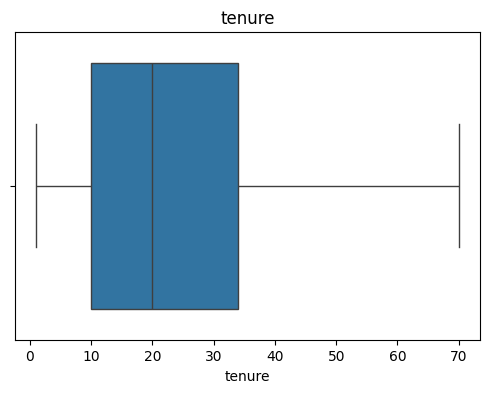

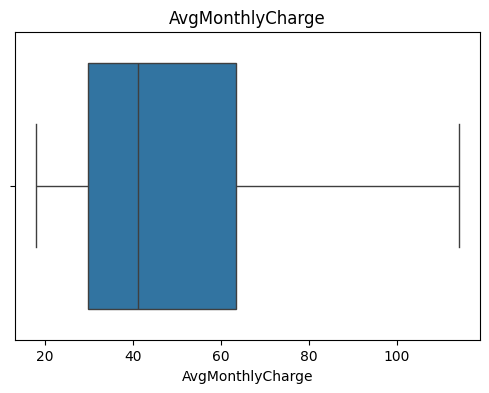

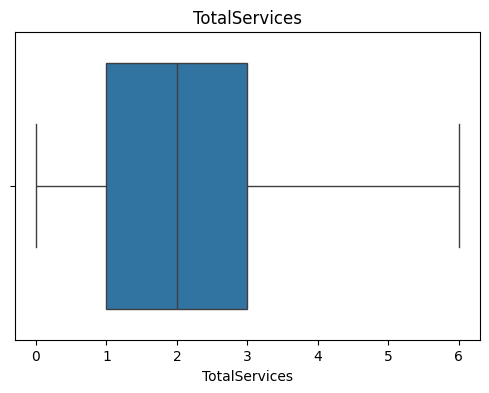

In [98]:
cols = ["tenure","AvgMonthlyCharge","TotalServices"]

for col in cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [99]:
cols = ["tenure","AvgMonthlyCharge","TotalServices"]

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

tenure : 0
AvgMonthlyCharge : 0
TotalServices : 0


In [100]:
cols = ["tenure","AvgMonthlyCharge","TotalServices"]

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

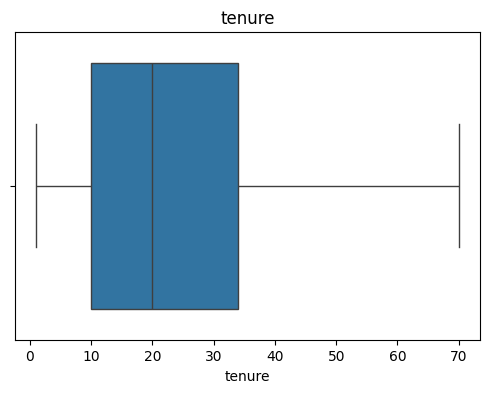

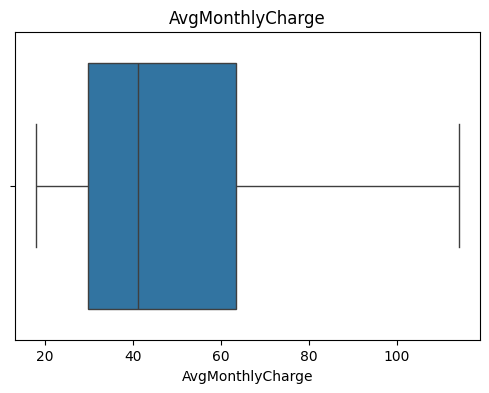

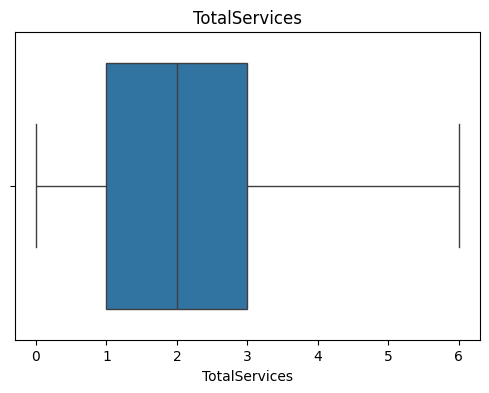

In [101]:
cols = ["tenure","AvgMonthlyCharge","TotalServices"]

for col in cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

**Outliers were detected using the IQR method. The columns tenure, AvgMonthlyCharge, and TotalServices contained outliers. Instead of removing the data, we applied clipping to limit extreme values while preserving the dataset size.**

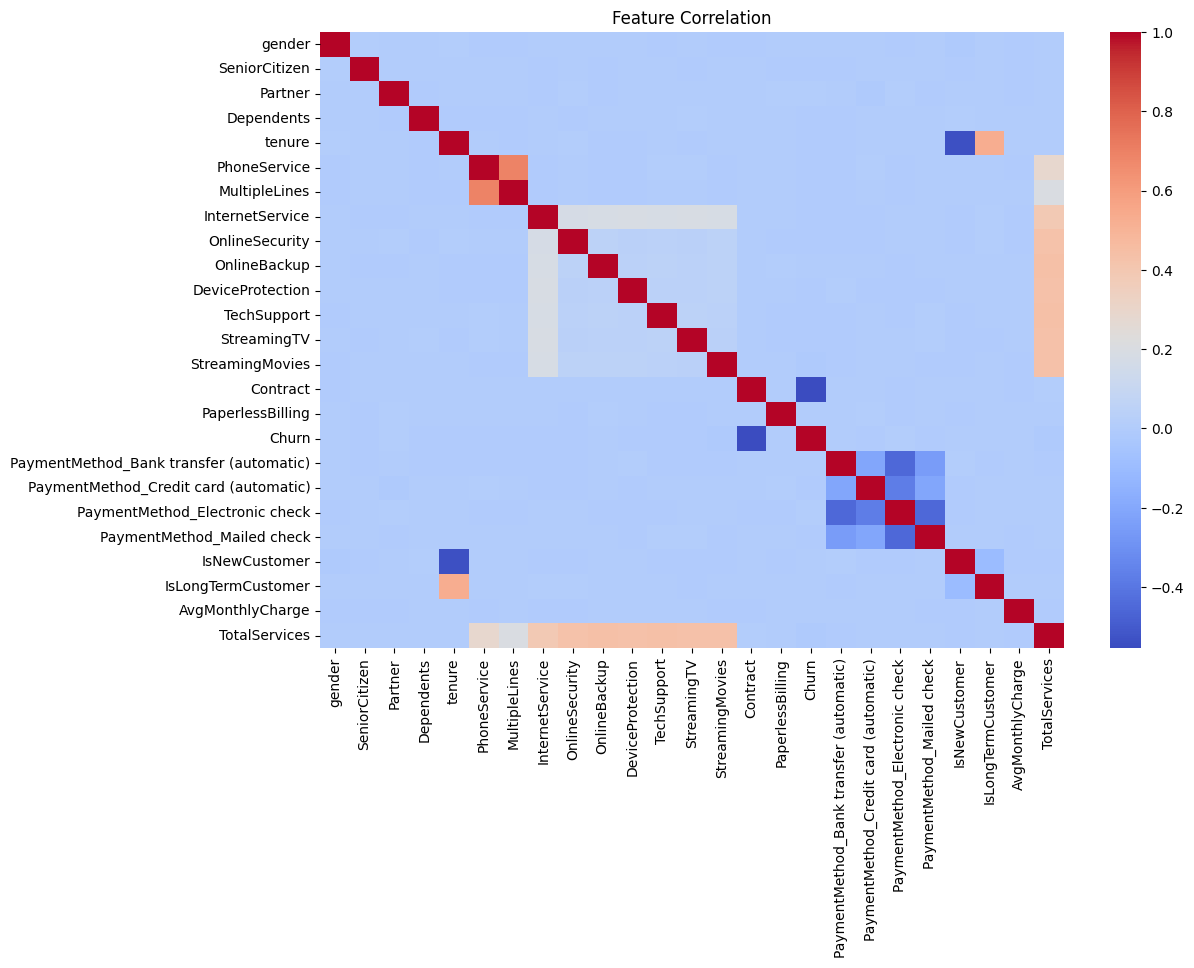

In [102]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

**Save Final Cleaned Dataset**

In [103]:
# Save the final cleaned dataset ready for analysis and modeling
df.to_csv("../data/telco_customer_data_cleaned.csv", index=False)

# **Great work my team!**
**the cleaned dataset uploaded to the github repository:**
